# Lab 2 — Chart Chooser and the First Honest Charts
### SDA-DSC-112 · Module 2 · Chart Selection and Design Principles · **50 minutes**

| | |
|---|---|
| **Objective** | For the Tayseer analytical questions, select the correct chart via the decision procedure and build each one honestly, applying all five design principles |
| **Dataset** | `tayseer_services.csv` · `tayseer_transactions_sample.csv` · `lab2_questions.csv` · `chart_chooser.csv` · `kpi_targets.csv` |
| **Output** | Four principle-compliant charts with takeaway titles, plus one interactive Plotly line as a Module 4 preview |

| Task | Minutes |
|---|---|
| 1 · Read the questions and recompute the programme scoreboard | 5 |
| 2 · Choose the chart for each question, and justify it | 10 |
| 3 · Build Q1–Q4 (and Q5 if you have time) | 20 |
| 4 · Add the reference lines | 5 |
| 5 · Q2 as an interactive Plotly line | 5 |
| 6 · Export, and kill a dual axis with indexed lines | 5 |

**The five design principles** — every chart below obeys all five:
1. honest baseline · 2. sort by value · 3. direct labelling over legends ·
4. reference lines · 5. small multiples for a third dimension.

### Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tayseer_viz as tv
tv.apply_theme()

df = tv.load_facts()
txn = tv.load("tayseer_transactions_sample.csv")
print(f"facts: {len(df):,} rows   transactions sample: {len(txn):,} rows")

# Your figures go to out/starter/ so they never overwrite the reference set.
tv.set_out_dir(tv.OUT / "starter")

facts: 28,080 rows   transactions sample: 20,000 rows


PosixPath('/home/claude/work/pkg/notebooks/out/starter')

---
## Task 1 — Read the questions and recompute the programme scoreboard *(5 min)*

`lab2_questions.csv` holds the analytical questions; `chart_chooser.csv` holds the
decision table. Read both **before** you draw anything — the chart is a function of the
question, not of the data type alone.

Then rebuild the programme scoreboard from first principles. Every KPI here is
**non-additive**: the weight comes from `kpi_targets.csv`, not from habit.

| KPI | Formula (from `kpi_targets.csv`) | Weight |
|---|---|---|
| KPI-01 Digital adoption % | `SUM(adoption/100 × unique_users) / SUM(unique_users) × 100` | `unique_users` |
| KPI-02 Cost per transaction | `SUM(cost × transactions) / SUM(transactions)` | `transactions` |
| KPI-03 CSAT | `SUM(csat × transactions) / SUM(transactions)` | `transactions` |
| KPI-04 Avg completion time | `SUM(minutes × transactions) / SUM(transactions)` | `transactions` |
| KPI-05 SLA met % | `SUM(sla × transactions) / SUM(transactions)` | `transactions` |

In [2]:
questions = tv.load("lab2_questions.csv")
chooser = tv.load("chart_chooser.csv")
pd.set_option("display.max_colwidth", 60)
display(questions[["question_id", "question", "question_type", "expected_chart"]])
display(chooser[["question_type", "default_chart", "if_many_categories", "avoid"]])

first, last = df[df.month == df.month.min()], df[df.month == df.month.max()]

# --- TODO -----------------------------------------------------------------
# Build `scoreboard`: one row per KPI-01..KPI-05, columns
#   ['KPI', 'Jul 2021', 'Jun 2026', '2026 target', 'direction'].
# Use tv.adoption / tv.cost_per_txn / tv.csat / tv.completion_min / tv.sla_met —
# each already implements its kpi_targets.csv formula. Do NOT use .mean().
scoreboard = None
# --------------------------------------------------------------------------

if scoreboard is None:
    print("TODO not implemented yet — expected a (5, 5) table whose published figures are:")
    print("  adoption 34.2 -> 63.8 %   cost 25.66 -> 16.94 SAR   CSAT 3.71 -> 4.16")
else:
    display(scoreboard.round(2))
    assert round(scoreboard.loc[scoreboard.KPI.str.startswith("Cost"), "Jun 2026"].iloc[0], 2) == 16.94
    print("ok — reconciles with the package's published figures")

,question_id,question,question_type,expected_chart
0,Q1,Which regions are lagging on digital adoption?,Comparison (ranking),Sorted horizontal bar
1,Q2,Is the national adoption trend improving or flattening?,Trend over time,Line chart with the 65% reference line
2,Q3,How does completion time vary across service categories?,Distribution,Box plot (not a bar of averages)
3,Q4,Does satisfaction move with cost per transaction?,Relationship,Scatter with a trend line
4,Q5,Thirteen overlapping regional lines - what is the fix?,Trend over time (many series),Small multiples or highlight-one


,question_type,default_chart,if_many_categories,avoid
0,Comparison (ranking),Sorted bar / dot plot,Dot plot (compact),"Pie, 3D bar, choropleth as primary"
1,Trend over time,Line chart,Small multiples,"Dual-axis line, truncated bar"
2,Distribution,Histogram / box plot,Violin / strip plot,Bar of averages (hides the tail)
3,Relationship,Scatter plot,Scatter + trend line,Dual-axis line (invents a crossing)
4,Part-to-whole,100% stacked bar,Treemap (with care),"Pie with 7+ slices, donut, 3D pie"
5,Geospatial how-much,Sorted bar first,Bar + supporting map,Choropleth alone (area shouts)
6,Deviation from target,Diverging bar centred on target,Dot plot with reference line,Sequential palette on diverging data
7,Flow / conversion,Funnel / step chart,Sankey (few nodes),Stacked area with many bands


TODO not implemented yet — expected a (5, 5) table whose published figures are:
  adoption 34.2 -> 63.8 %   cost 25.66 -> 16.94 SAR   CSAT 3.71 -> 4.16


---
## Task 2 — Choose the chart for each question *(10 min)*

Two-step lookup, every time:

**Step 1 — name the question type** (comparison, trend, distribution, relationship,
part-to-whole, geospatial).
**Step 2 — apply the data shape** (how many categories, series, points) to pick within
the family.

Write your choice and your reason for each question. Cite the decision table, not taste.

In [3]:
# --- TODO -----------------------------------------------------------------
# Build `choices`: one row per question Q1..Q5 with columns
#   ['q', 'question', 'question_type', 'chosen_chart', 'n_categories', 'n_series', 'why'].
# `why` must cite the decision procedure (question type + data shape + encoding channel),
# not "it looks clearer".
choices = None
# --------------------------------------------------------------------------

if choices is None:
    print("TODO not implemented yet — expected 5 rows. Compare your answers against")
    print("  questions[['question_id', 'expected_chart', 'rationale']] once you are done.")
else:
    display(choices[["q", "question_type", "chosen_chart", "why"]])
    expected = dict(zip(questions.question_id, questions.expected_chart))
    for _, r in choices.iterrows():
        print(f"{r.q}: mine={r.chosen_chart:<34} package={expected[r.q]}")

TODO not implemented yet — expected 5 rows. Compare your answers against
  questions[['question_id', 'expected_chart', 'rationale']] once you are done.


---
## Task 3 — Build Q1–Q4 *(20 min)*

Every chart: honest baseline, sorted where a ranking exists, direct labels instead of a
legend, and a **takeaway title** that states the conclusion rather than the subject.

/home/claude/work/pkg/notebooks/out/starter/lab2_q1_sorted_bar.png


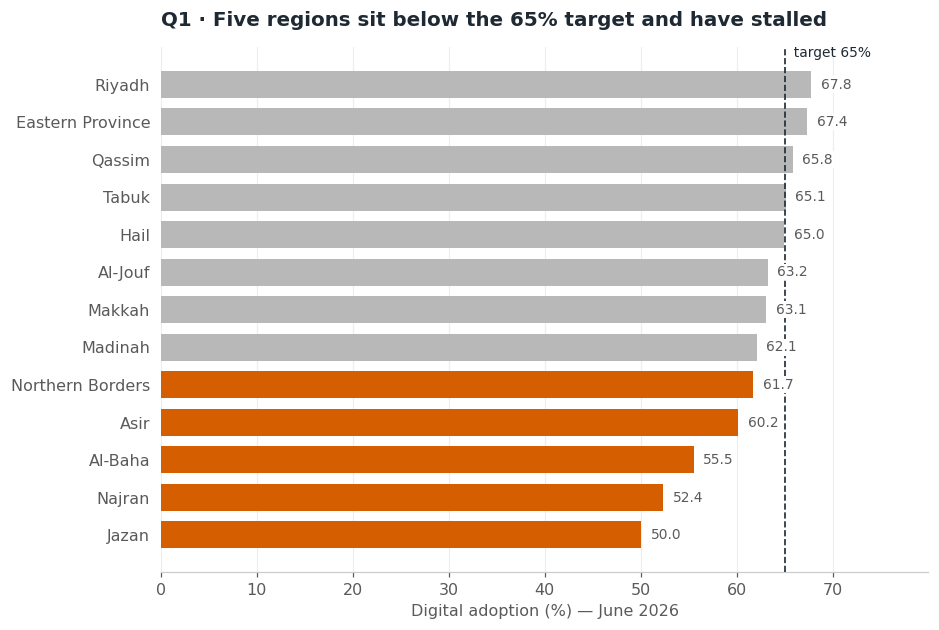

TODO not implemented yet. Expected:
  Q2 -> 60-row month series, ends at 63.8%, never crosses 65
  Q3 -> box plot; Justice & Notary and Business & Licensing carry the tail
  Q4 -> 13 points, Pearson r about -0.60


In [4]:
latest = df[df.month == df.month.max()]

# ---------- Q1 — comparison / ranking (WORKED EXAMPLE) ------------------
q1 = (tv.by(latest, "region", "digital_adoption_pct")
        .rename(columns={"digital_adoption_pct": "adoption_pct"}))
fig, ax = plt.subplots(figsize=(9, 6.2))
tv.sorted_bar(q1, "region", "adoption_pct", highlight=tv.STALLED,
              title="Q1 · Five regions sit below the 65% target and have stalled",
              xlabel="Digital adoption (%) — June 2026",
              reference=tv.TARGET_ADOPTION, reference_label="target 65%", ax=ax)
print(tv.save_fig(fig, "lab2_q1_sorted_bar")); plt.show()

# --- TODO -----------------------------------------------------------------
# Q2  national adoption trend.
#       q2 = tv.by(df, "month", "digital_adoption_pct").sort_values("month")
#       Line chart. Y from 0. Direct-label the last point AND the target line.
# Q3  completion-time distribution, from `txn` (the 20k transaction sample).
#       Build BOTH: the wrong bar-of-means and the right box plot, side by side.
#       Order categories by p95 so the tail ordering is visible.
# Q4  CSAT vs cost per transaction, one point per region, latest month.
#       tv.by(latest, "region", "csat") merged with tv.by(latest, "region", "cost_per_txn_sar")
#       Scatter + a np.polyfit trend line + direct region labels. NEVER a dual axis.
q2 = q3_done = q4 = None
# --------------------------------------------------------------------------

if q2 is None:
    print("TODO not implemented yet. Expected:")
    print("  Q2 -> 60-row month series, ends at 63.8%, never crosses 65")
    print("  Q3 -> box plot; Justice & Notary and Business & Licensing carry the tail")
    print("  Q4 -> 13 points, Pearson r about -0.60")
else:
    assert len(q2) == 60, len(q2)
    print("ok")

---
## Task 4 — The reference lines *(5 min)*

A reference line turns a chart of numbers into a chart of **judgements**. Q1 gets the
national mean, Q2 gets the 65% target. Both are already in the charts above — this task
is to *verify* them and to show what the chart looks like without.

In [5]:
# --- TODO -----------------------------------------------------------------
# Render Q1 twice, side by side: once bare, once with BOTH reference lines
# (the 65% target and the user-weighted national mean). Save to
# out/starter/lab2_reference_lines.png. Then print how many regions are below target.
REFERENCE_DONE = False
# --------------------------------------------------------------------------

if not REFERENCE_DONE:
    print("TODO not implemented yet — expected: 2-panel figure, and")
    print("  'regions below target' = 9   (this is KPI-08 in kpi_targets.csv)")

TODO not implemented yet — expected: 2-panel figure, and
  'regions below target' = 9   (this is KPI-08 in kpi_targets.csv)


---
## Task 5 — Q2 as an interactive Plotly line *(5 min)*

A preview of Module 4. Hover shows the exact monthly value; the target stays a reference
line, not a second series. Nothing about the *design* changes because the medium changed.

In [6]:
import plotly.graph_objects as go

# --- TODO -----------------------------------------------------------------
# Rebuild Q2 in Plotly:
#   go.Scatter(x=..., y=..., mode="lines", hovertemplate=...)
#   figp.add_hline(y=65, line_dash="dash", ...)
#   template="plotly_white", showlegend=False, takeaway title
# Then figp.write_html(tv.OUT / "lab2_q2_interactive.html", include_plotlyjs="cdn")
figp = None
# --------------------------------------------------------------------------

if figp is None:
    print("TODO not implemented yet — expected an interactive line whose hover reads")
    print("  'Jun 2026 / adoption 63.8%', with the target as a reference line (not a series).")
else:
    figp.show()

TODO not implemented yet — expected an interactive line whose hover reads
  'Jun 2026 / adoption 63.8%', with the target as a reference line (not a series).


---
## Task 6 — Export, and kill a dual axis with indexed lines *(5 min)*

The Module 1 case study's other villain was a **dual-axis** line overlaying satisfaction
(1–5) and cost (SAR), scaled so the lines crossed — which the committee read as causation.

The fix is not a prettier dual axis. It is to **index both series to their first month =
100** so they share one honest axis. Build the villain and the fix side by side, then
export everything.

In [7]:
# --- TODO -----------------------------------------------------------------
# 1. nat = monthly CSAT and cost, each recomputed correctly (tv.by), indexed on month.
# 2. idx = nat / nat.iloc[0] * 100
# 3. Two panels: LEFT the dual-axis villain (ax.twinx()), RIGHT the indexed fix.
#    Direct-label both lines on the right panel; no legend.
# 4. Save to out/starter/lab2_indexed_lines.png and list everything you exported.
idx = None
# --------------------------------------------------------------------------

if idx is None:
    print("TODO not implemented yet — expected: satisfaction +12%, cost per transaction -34%")
else:
    print(f"satisfaction {idx.csat.iloc[-1]-100:+.0f}%, cost {idx.cost_per_txn_sar.iloc[-1]-100:+.0f}%")
    assert round(idx.cost_per_txn_sar.iloc[-1] - 100) == -34
    print("ok")

TODO not implemented yet — expected: satisfaction +12%, cost per transaction -34%


---
## Lab 2 checklist

- [ ] Task 1 — scoreboard reconciles: 25.66 → 16.94 SAR, 3.71 → 4.16 CSAT
- [ ] Task 2 — a chart chosen and justified for all five questions
- [ ] Task 3 — Q1–Q4 built; every one has a takeaway title, not a topic title
- [ ] Task 4 — both reference lines present; nine regions below target
- [ ] Task 5 — interactive Plotly line written to HTML
- [ ] Task 6 — dual axis retired; indexed lines show +12% / −34%

Save your work as `lab2_solution.ipynb`.

---

## Section 2b — Normalisation and the per-capita flip  *(35 min · Case C)*

The committee asked "who is underserved?" and was handed a chart that answers "where is the work?".
Those are different questions with different denominators, and the ranking inverts between them.

Data: `tayseer_services.csv`, `dim_regions.csv`, and `regional_equity_latest.csv` (the reference answer).


### Task 1 · (5 min) Two denominators

Compute, for the latest month: total **digital** transactions by region (Mobile App + Web Portal),
and the same figure divided by `population_2025`, expressed per 1,000 residents.

In [8]:
import tayseer_viz as tv
import pandas as pd, numpy as np, matplotlib.pyplot as plt
tv.apply_theme()

df   = tv.load_facts()
dims = tv.load("dim_regions.csv")
chan = tv.load("dim_channels.csv")
latest = df[df.month == df.month.max()]

# TODO: build `eq`, indexed by region, with columns
#       digital_transactions · population_2025 · digital_txn_per_1k
#       (digital channels are the rows where dim_channels.is_digital is Yes)
eq = None

if eq is None:
    print("TODO not implemented yet — expected a 13-row frame; national rate ~225 per 1,000")
else:
    print(eq.round(1).to_string())

TODO not implemented yet — expected a 13-row frame; national rate ~225 per 1,000


### Task 2 · (8 min) Rank twice, and measure the shift

Draw both as sorted horizontal bars with the five Tier-1 regions accented. Then compute `rank_shift`
and name the largest mover in each direction.

In [9]:
# TODO: add rank_by_raw_volume, rank_by_per_capita and rank_shift to `eq`,
#       then draw the two sorted horizontal bar charts side by side with
#       the five Tier-1 regions (tv.STALLED) accented in tv.ACCENT.
ranked = None
if ranked is None:
    print("TODO not implemented yet — expected the largest downward mover to fall 6 places")

TODO not implemented yet — expected the largest downward mover to fall 6 places


### Task 3 · (7 min) What is this map a map OF?

Draw the raw-count view as a *map-like* object — regions ordered by geography is enough here —
then answer in writing: what is a raw-count choropleth actually a map of? Keep the answer.
It is the punchline of Case C.

In [10]:
# TODO: correlate population against raw digital transactions and plot it.
#       Then write your one-sentence answer to "what is this a map OF?" in the cell below.
r = None
if r is None:
    print("TODO not implemented yet — expected a correlation above 0.98")

TODO not implemented yet — expected a correlation above 0.98


### Task 4 · (6 min) Lorenz and Gini — and whether they belong

Build the Lorenz curve of digital transactions against population and compute the Gini.
Then decide whether it goes in the deck. Justify the decision in one sentence — including if the answer is no.

In [11]:
# TODO: sort by the per-capita rate, build cumulative population and transaction shares,
#       compute the Gini by the trapezoid rule, and plot the Lorenz curve.
gini = None
if gini is None:
    print("TODO not implemented yet — expected a Gini below 0.05, and a decision NOT to ship it")

TODO not implemented yet — expected a Gini below 0.05, and a decision NOT to ship it


### Task 5 · (6 min) The subtitle that states the denominator

Write the chart subtitle in under 15 words. It must carry the measure, the denominator, the month
and the target. Then (Task 6, 3 min) have your partner read only the subtitle and describe the chart back to you.

In [12]:
# TODO: write the subtitle (under 15 words: measure, denominator, month, target/national),
#       then redraw the per-capita chart with a narrative title and that subtitle.
subtitle = None
if subtitle is None:
    print("TODO not implemented yet — expected something like")
    print("'Digital transactions per 1,000 residents, <month> — national <rate>'")

TODO not implemented yet — expected something like
'Digital transactions per 1,000 residents, <month> — national <rate>'
